In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from walkforward_parameter_search import compute_grid_size
from synthetic_returns import estimate_marginal_stats, synthesize_returns
set_config(transform_output="pandas")
init_logger("CSCV_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\CSCV_252.log


In [79]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
log_print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


In [3]:
from cscv_pbo import cscv_pbo,plot_cscv

In [98]:
from cscv_pbo_v2 import cscv_pbo, plot_cscv

In [124]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 10},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'extremes__k': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 252}}  # inner train size
log_print(search_space, section='Search Space', echo=False)
compute_grid_size(search_space)

4860

In [125]:
cscv_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 10,
  'n_trials': 5000,
  'patience': 200,
  'sampler': 'random',
  'min_delta': 0.0001,
  'seed': 24,
  'inner_purged_size': 2,
  'inner_embargo_size': 2,
  'candidate_mode': 'all',
  'top_k': 50,
  'S': 16,
  'verbose': True}
log_print(cscv_params, section='Parameter Space', echo=False)

In [126]:
out = cscv_pbo(X, space=search_space, mat_n_jobs=6, **cscv_params)

  0%|          | 0/5000 [00:00<?, ?it/s]

  收益流构建(v2 cross_val_predict，fold 并行 n_jobs=6)：3086 参数 x 6 块 x 252 天 = 1512 天


收益流构建:   0%|          | 0/3086 [00:00<?, ?候选/s]

In [127]:
import pickle, json
pickle.dump(out, open("cscv_out_seed24_5000.pkl", "wb"))                      # 首选:整份留档
json.dump(out["candidates"], open("candidates_seed24_500.json", "w"), default=str)  # 兜底:至少留候选参数

In [128]:
log_print( out["report"], section="CSCV PBO 诊断", echo=True)

       CSCV PBO 诊断（标准版：单次搜索 + 静态参数族）
  搜索：trials=5000 | sampler=random | 候选 all = 3086 | 搜索段 1008 天
  收益流：3086 参数 x 6 块 x 252 天 = 1512 天
  评估区：2020-02-27 00:00:00+08:00 ~ 2026-05-25 00:00:00+08:00
  CSCV：S=16 块（每块 94 天）| 组合数 C(16,8) = 12870
  PBO = freq(lambda<=0) = 13.4%（1720/12870）
  lambda 分位：5%=-1.28 | 50%=+2.05 | 95%=+5.32
  IS 冠军多样性：124/3086 个不同候选被选为冠军
  解读：PBO 越接近 0 排名传递性越好；>50% 严重预警（IS 最优比随机挑还不可信）


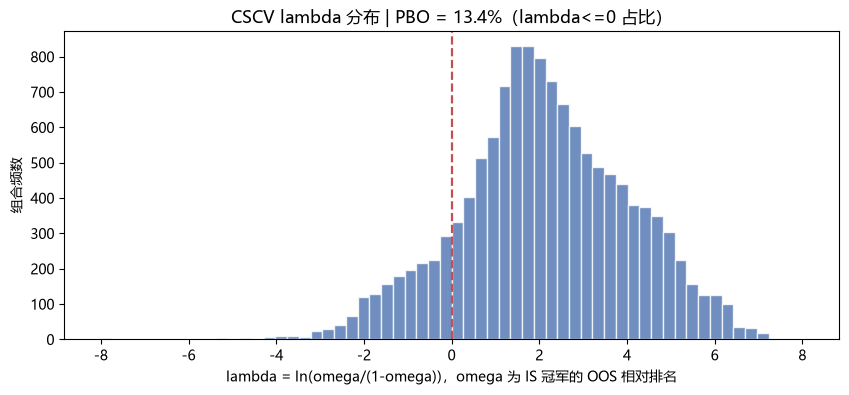

In [129]:
plot_cscv(out)                                          # lambda 分布图

#### 复用搜索结果

实验 1（窗效应，最有信息量）：固定本轮这 108 个候选，把评估窗扩回含 2020-02 ~ 2021-02。做法：把数据准备 cell 的过滤临时改回 >2015 重跑得到 X_long，然后：

In [ ]:
import importlib, cscv_pbo as m
importlib.reload(m)

M = m.build_returns_matrix(X, out["candidates"], start=cscv_params['train_size'],
                           block_size=cscv_params['test_size'])
core = m.cscv_core(M.to_numpy(), S=16)
print(f"PBO（窗含 2020-02~2021-02）= {core['pbo']:.1%}")

实验 2（挖"全能者"）：看是谁在霸榜：

In [130]:
vc = pd.Series(out["n_star"]).value_counts()
print(vc.head(8))
for idx in vc.head(10).index: print(int(vc[idx]), out["candidates"][idx])

2351    2915
1000    1979
1277    1389
108     1152
1251     776
216      513
1279     411
3020     361
Name: count, dtype: int64
2915 {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
1979 {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-kurt', 'train_size': 504}
1389 {'nondomin__min_n_assets': 25, 'nondomin__threshold': -0.3, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-mad-maxdd-cvar-sharpe', 'train_size': 252}
1152 {'nondomin__min_n_assets': 15, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-kurt', 'train_size': 252}
776 {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'no

实验 3:主力闭环核验

[数据来源] 零重算 | 候选 N=3086 x 评估区 T=1512 天 | 对称组合 12870 个 | S=16
[top3 定位(夺冠次数 | 参数)]
  2915  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
  1979  {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-kurt', 'train_size': 504}
  1389  {'nondomin__min_n_assets': 25, 'nondomin__threshold': -0.3, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-mad-maxdd-cvar-sharpe', 'train_size': 252}

[评估区整体指标(1512 天,复利口径)]
            年化收益    年化波动  Sharpe    最大回撤     日胜率
cand2351  0.1131  0.0730  1.5056 -0.1103  0.5529
cand1000  0.1235  0.0793  1.5084 -0.1148  0.5489
cand1277  0.0977  0.0777  1.2401 -0.1221  0.5939
全体-中位     0.0484  0.1089  0.5197 -0.2275  0.5218
全体-95分位   0.0951  0.1780  0.9313 -0.1009  0.5522

[当选组合口径 | Sharpe 为日频未年

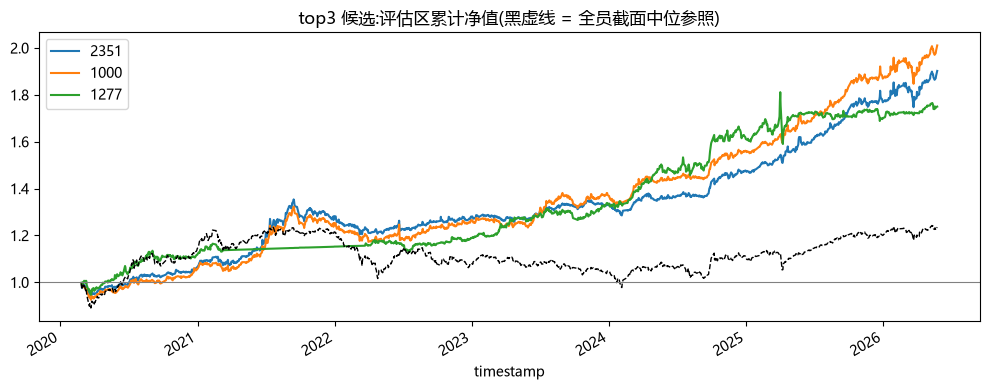

In [131]:
# ============================================================
# 实验3 主力闭环核验:top3 冠军候选的样本外验收
# 零重算(直接消费 out);全部输出经 log_print 落盘 logs/CSCV_252.log
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SECTION = "实验3 主力闭环核验"

M  = out["matrix"]                              # 3134 列 x 1512 天 评估区收益流
vc = pd.Series(out["n_star"]).value_counts()    # 12870 个组合的 IS 冠军频次
top3_idx = [int(i) for i in vc.head(3).index]

ns    = np.asarray(out["n_star"])
s_is  = np.asarray(out["sel_sharpe_is"])
s_oos = np.asarray(out["sel_sharpe_oos"])
om    = np.asarray(out["omega"])

lines = []
lines.append(f"[数据来源] 零重算 | 候选 N={len(M.columns)} x 评估区 T={len(M)} 天 | "
             f"对称组合 {len(ns)} 个 | S={out.get('S', '?')}")
lines.append("[top3 定位(夺冠次数 | 参数)]")
for i in top3_idx:
    lines.append(f"  {int(vc[i])}  {out['candidates'][i]}")

# ---------- 1) 评估区整体表现(对照全体 3134 条流) ----------
def stats(r):
    cum = (1 + r).cumprod()
    return pd.Series({
        "年化收益": cum.iloc[-1] ** (252 / len(r)) - 1,
        "年化波动": r.std() * np.sqrt(252),
        "Sharpe":  r.mean() / r.std() * np.sqrt(252),   # 日频比率年化,无风险利率取 0
        "最大回撤": (cum / cum.cummax() - 1).min(),
        "日胜率":  (r > 0).mean(),
    })

tbl     = pd.DataFrame({f"cand{i}": stats(M[i]) for i in top3_idx}).T
all_tbl = pd.DataFrame({i: stats(M[i]) for i in M.columns}).T
tbl.loc["全体-中位"]   = all_tbl.median()
tbl.loc["全体-95分位"] = all_tbl.quantile(0.95)
lines.append("")
lines.append("[评估区整体指标(1512 天,复利口径)]")
lines.append(tbl.round(4).to_string())

# ---------- 2) 当选口径(该候选为 IS 冠军的组合子集) ----------
lines.append("")
lines.append("[当选组合口径 | Sharpe 为日频未年化;OOS 分位 = omega 排名分位(越高越靠前)]")
for i in top3_idx:
    m = ns == i
    lines.append(
        f"  cand{i:>4}: 当选 {m.sum():>5} 次({m.mean():>6.1%}) | "
        f"IS-Sharpe 中位 {np.median(s_is[m]):+6.2f} | OOS-Sharpe 中位 {np.median(s_oos[m]):+6.2f} | "
        f"OOS 分位中位 {np.median(om[m]):>5.1%} | 掉后半占比 {(om[m] <= 0.5).mean():>5.1%}")

w    = np.array([(ns == i).sum() for i in top3_idx]) / len(ns)
cond = np.array([(om[ns == i] <= 0.5).mean() for i in top3_idx])
lines.append(
    f"  汇总: top3 合计份额 {w.sum():.1%} | top3 加权贡献 lambda<=0 频率 {np.sum(w * cond):.1%} | "
    f"全组合 PBO {(om <= 0.5).mean():.1%}")

# 一次性落盘 + 控制台回显(echo=True)
log_print("\n".join(lines), section=SECTION, echo=True)

# ---------- 3) 评估区累计净值(图不进文本日志,如要留档取消下行注释) ----------
ax = (1 + M[top3_idx]).cumprod().plot(
    figsize=(10, 4), title="top3 候选:评估区累计净值(黑虚线 = 全员截面中位参照)")
(1 + M.median(axis=1)).cumprod().plot(ax=ax, style="k--", linewidth=1)
ax.axhline(1.0, color="gray", linewidth=0.8)
# plt.gcf().savefig("logs/实验3_top3_净值.png", dpi=150)   # ← 需留图表时启用
plt.tight_layout()
plt.show()